In [ ]:
# Load & Prepare Data
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned_dataset/cleaned_ticket_prices.csv")

df.head()

,month,conflict_phase,airline,iata_code,country,region,airline_type,route_class,avg_route_km,base_fare_usd,...,yoy_surcharge_change_pct,year,month_num,quarter,is_extreme_fare,fuel_surcharge_ratio,taxes_ratio,base_ratio,crude_jet_ratio,fare_per_km
0,2019-01,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1179.91,...,0.0,2019,1,2019Q1,False,0.0731,0.1171,0.8098,1.1838,0.1714
1,2019-02,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1176.08,...,0.0,2019,2,2019Q1,False,0.0468,0.0933,0.8599,1.2087,0.1609
2,2019-03,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1133.88,...,0.0,2019,3,2019Q1,False,0.0857,0.0876,0.8267,1.1672,0.1614
3,2019-04,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1237.95,...,0.0,2019,4,2019Q2,False,0.0402,0.1155,0.8442,1.1320,0.1725
4,2019-05,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1270.08,...,0.0,2019,5,2019Q2,False,0.0570,0.1119,0.8311,1.1913,0.1798


In [3]:
cols = [
    'jet_fuel_usd_barrel',
    'brent_crude_usd',
    'total_fare_usd',
    'fuel_cost_pct_opex',
    'yoy_price_change_pct',
    'load_factor_pct'
]

df_selected = df[cols]

In [4]:
df_selected.describe()

,jet_fuel_usd_barrel,brent_crude_usd,total_fare_usd,fuel_cost_pct_opex,yoy_price_change_pct,load_factor_pct
count,14355.000000,14355.000000,14355.000000,14355.000000,14355.000000,14355.000000
mean,93.624138,80.184368,1135.346773,0.280993,31.461953,70.321477
std,28.371276,24.359421,1468.411496,0.096425,99.103267,16.610219
min,23.690000,20.550000,13.890000,0.052000,-80.330000,31.000000
25%,76.870000,66.500000,146.460000,0.223000,-17.945000,64.900000
50%,94.920000,82.610000,470.560000,0.277000,0.000000,73.800000
75%,109.200000,91.480000,1565.400000,0.335000,21.685000,82.800000
max,193.200000,169.080000,12126.260000,0.733000,518.100000,92.000000


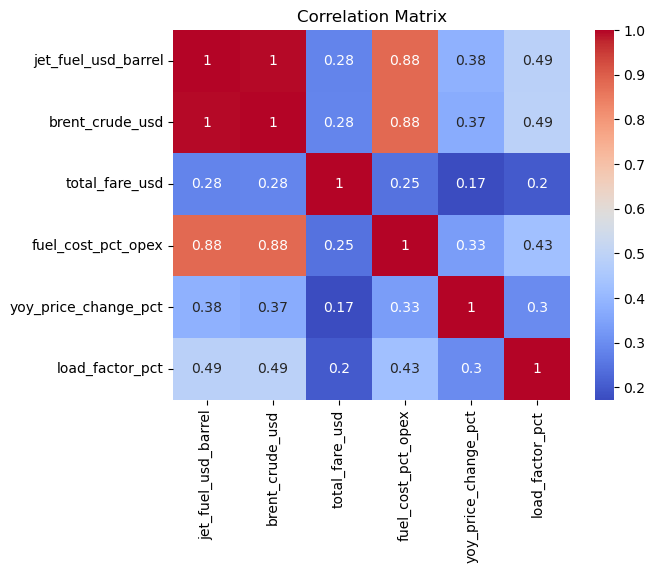

In [5]:
# Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_selected.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Correlation Analysis Insights

The correlation matrix shows that jet fuel price has a strong positive relationship with fuel cost percentage (~0.88), indicating that rising fuel prices significantly increase airline operating costs.

However, the relationship between fuel price and ticket price is weak (~0.28), suggesting that airlines do not fully pass fuel cost increases to customers.

Brent crude oil and jet fuel prices are almost perfectly correlated (~1), meaning they move together and one can be used for analysis.

Overall, fuel prices strongly impact costs but have limited direct influence on ticket pricing.

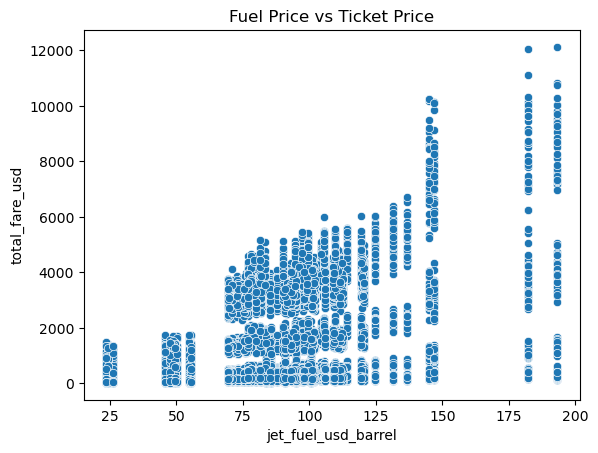

In [6]:
sns.scatterplot(x='jet_fuel_usd_barrel', y='total_fare_usd', data=df)
plt.title("Fuel Price vs Ticket Price")
plt.show()

In [7]:
import statsmodels.api as sm

X = df['jet_fuel_usd_barrel']
y = df['total_fare_usd']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         total_fare_usd   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     1231.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          9.96e-259
Time:                        13:17:54   Log-Likelihood:            -1.2445e+05
No. Observations:               14355   AIC:                         2.489e+05
Df Residuals:                   14353   BIC:                         2.489e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -226.3402    

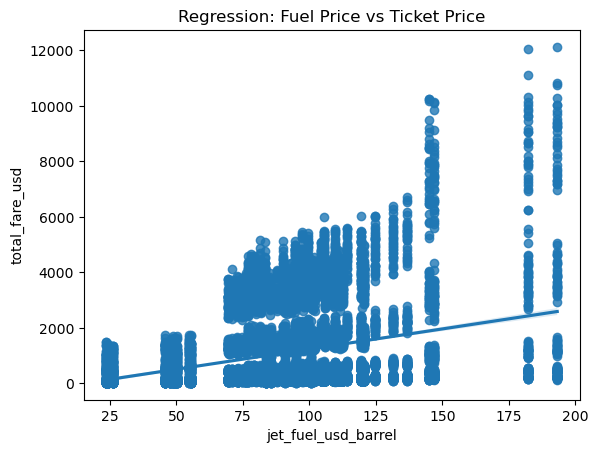

In [9]:
sns.regplot(x='jet_fuel_usd_barrel', y='total_fare_usd', data=df)
plt.title("Regression: Fuel Price vs Ticket Price")
plt.show()

In [10]:
X = df[['jet_fuel_usd_barrel', 'load_factor_pct']]
y = df['total_fare_usd']

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:         total_fare_usd   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     659.7
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          8.33e-275
Time:                        13:20:46   Log-Likelihood:            -1.2441e+05
No. Observations:               14355   AIC:                         2.488e+05
Df Residuals:                   14352   BIC:                         2.489e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -545.4133    

In [11]:
p_value = model.pvalues['jet_fuel_usd_barrel']

print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Fuel price significantly affects ticket price")
else:
    print("Fail to reject H0: No significant effect")

P-value: 9.956125346767485e-259
Reject H0: Fuel price significantly affects ticket price


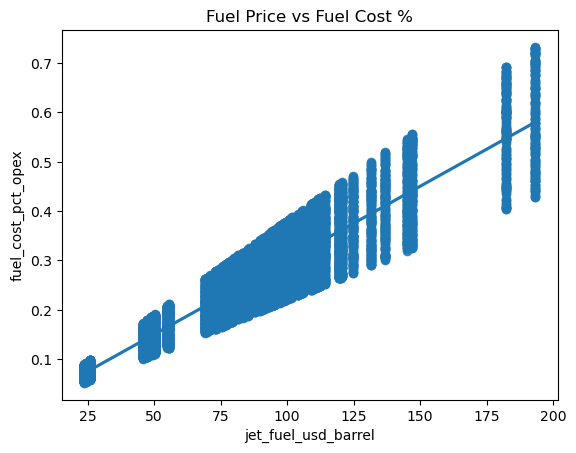

In [12]:
sns.regplot(x='jet_fuel_usd_barrel', y='fuel_cost_pct_opex', data=df)
plt.title("Fuel Price vs Fuel Cost %")
plt.show()

In [13]:
df.groupby('conflict_phase')['total_fare_usd'].mean().sort_values()

conflict_phase
COVID-19 Collapse         401.264929
Pre-Pandemic Baseline    1016.689468
Gaza-Israel Conflict     1133.829048
Stabilisation            1154.232054
Pre-Iran Escalation      1197.394020
Recovery & Surge         1293.678781
Ukraine War Shock        1560.867891
US-Iran War Conflict     2660.082864
Name: total_fare_usd, dtype: float64

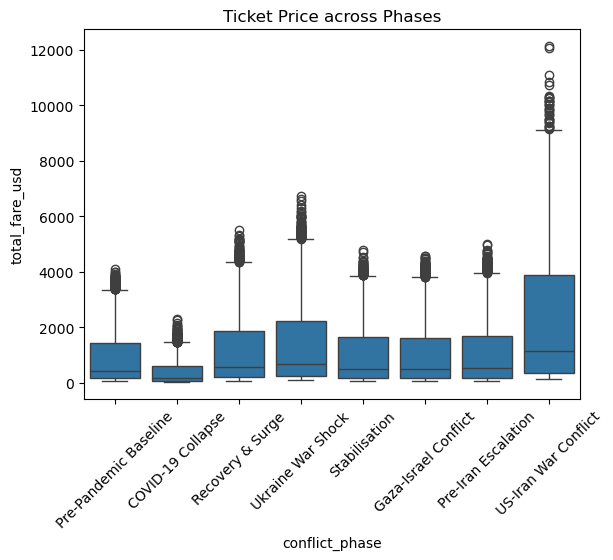

In [14]:
sns.boxplot(x='conflict_phase', y='total_fare_usd', data=df)
plt.xticks(rotation=45)
plt.title("Ticket Price across Phases")
plt.show()